<a href="https://colab.research.google.com/github/Rakesh-2211/Matched-filtering-ISI-and-eye-diagram/blob/main/Exp_08_Matched_filtering_%2C_ISI_and_eye_diagram_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Mandatory Validation ---
Filter Length: 49 samples
Total Cascade Delay (Tx + Rx): 48 samples
Sampling occurs only AFTER removing 48 samples.
------------------------------


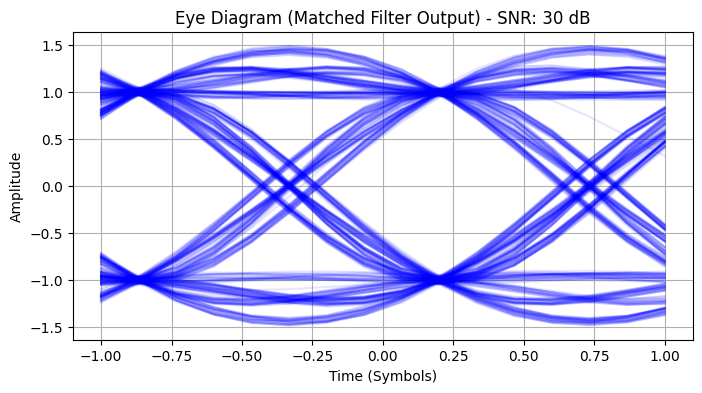

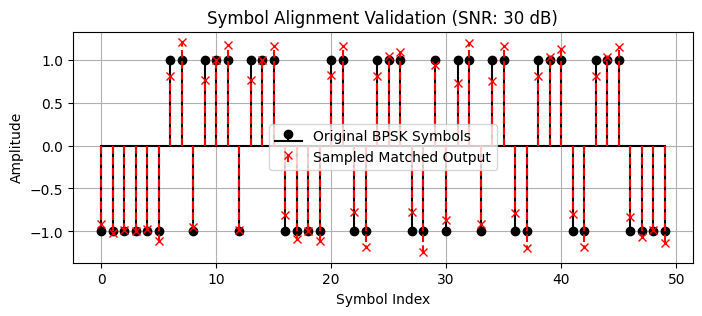

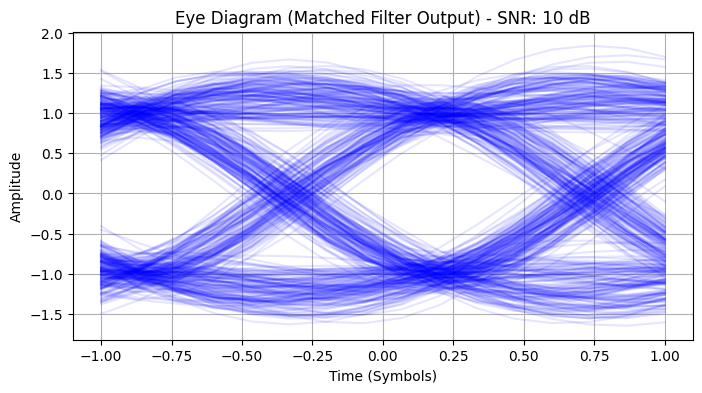

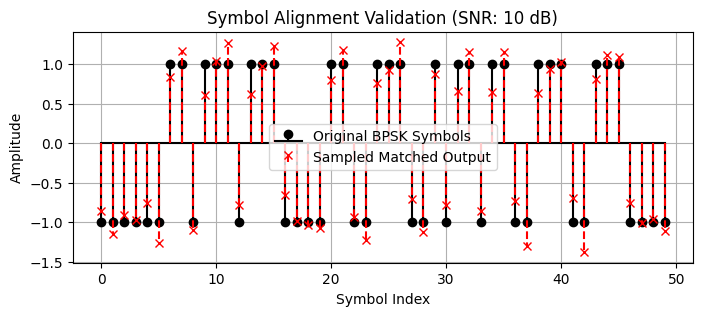

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Core Functions (No Comm Toolbox Used)
# ==========================================

def rrcosfilter(N, alpha, Ts, Fs):
    """
    Generates a Root Raised Cosine (RRC) filter.
    N: Filter length in samples
    alpha: Roll-off factor
    Ts: Symbol period
    Fs: Sampling rate
    """
    T_delta = 1 / Fs
    h_rrc = np.zeros(N, dtype=float)

    for x in range(N):
        t = (x - N/2) * T_delta
        if t == 0.0:
            h_rrc[x] = 1.0 - alpha + (4 * alpha / np.pi)
        elif alpha != 0 and np.isclose(abs(t), Ts / (4 * alpha)):
            h_rrc[x] = (alpha / np.sqrt(2)) * (((1 + 2 / np.pi) * (np.sin(np.pi / (4 * alpha)))) + ((1 - 2 / np.pi) * (np.cos(np.pi / (4 * alpha)))))
        else:
            h_rrc[x] = (np.sin(np.pi * t * (1 - alpha) / Ts) + 4 * alpha * (t / Ts) * np.cos(np.pi * t * (1 + alpha) / Ts)) / (np.pi * t * (1 - (4 * alpha * t / Ts)**2) / Ts)

    # Normalize energy
    return h_rrc / np.sqrt(np.sum(h_rrc**2))

def plot_eye_diagram(signal, sps, title="Eye Diagram"):
    """
    Reusable eye diagram function without a communication toolbox.
    Plots overlays of the signal spanning 2 symbols.
    """
    samples_per_trace = 2 * sps
    num_traces = len(signal) // samples_per_trace

    plt.figure(figsize=(8, 4))
    # Reshape signal into traces and plot simultaneously for efficiency
    traces = np.reshape(signal[:num_traces * samples_per_trace], (num_traces, samples_per_trace))
    t_axis = np.linspace(-1, 1, samples_per_trace)

    plt.plot(t_axis, traces.T, color='blue', alpha=0.1)
    plt.title(title)
    plt.xlabel("Time (Symbols)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

# ==========================================
# 2. System Parameters
# ==========================================
num_symbols = 1000       # Number of BPSK symbols to transmit
sps = 8                  # Samples per symbol
span = 6                 # Filter span in symbols
alpha = 0.5              # Roll-off factor
Ts = 1.0                 # Symbol time
Fs = sps                 # Sampling frequency

# Derived filter parameters
filter_len = span * sps + 1
# The delay introduced by a single FIR filter is (filter_len - 1) / 2
# The cascade of two such filters introduces twice that delay.
total_cascade_delay = filter_len - 1

# ==========================================
# 3. Transmitter & Channel Simulation
# ==========================================

# Generate BPSK symbols (-1, 1)
bits = np.random.randint(0, 2, num_symbols)
symbols = 2 * bits - 1

# Upsample symbols
tx_up = np.zeros(num_symbols * sps)
tx_up[::sps] = symbols

# Generate RRC Filter
h_rrc = rrcosfilter(filter_len, alpha, Ts, Fs)

# Pulse shaping (Transmit Filter)
tx_sig = np.convolve(tx_up, h_rrc, mode='full')

def simulate_matched_filter(tx_sig, snr_db, timing_offset=0):
    # Add AWGN
    snr_linear = 10 ** (snr_db / 10)
    signal_power = np.mean(tx_sig**2)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.randn(len(tx_sig))
    rx_sig = tx_sig + noise

    # Matched Filtering (Receive Filter)
    rx_matched = np.convolve(rx_sig, h_rrc, mode='full')

    # ----------------------------------------------------
    # MANDATORY VALIDATION: Delay Removal & Optimum Sampling
    # ----------------------------------------------------
    # We drop the first 'total_cascade_delay' samples.
    # Valid symbols start exactly after this point.
    optimum_sample_idx = total_cascade_delay + timing_offset

    # Extract sampled symbols
    detected_symbols = rx_matched[optimum_sample_idx :: sps][:num_symbols]

    return rx_matched, detected_symbols

# ==========================================
# 4. Visualizations & Validations
# ==========================================

print(f"--- Mandatory Validation ---")
print(f"Filter Length: {filter_len} samples")
print(f"Total Cascade Delay (Tx + Rx): {total_cascade_delay} samples")
print(f"Sampling occurs only AFTER removing {total_cascade_delay} samples.")
print("-" * 30)

# Test multiple SNRs and plot Eye Diagrams
snr_test_cases = [30, 10]  # High SNR, Low SNR

for snr in snr_test_cases:
    rx_matched, detected_symbols = simulate_matched_filter(tx_sig, snr_db=snr, timing_offset=0)

    # Plot Eye Diagram of the continuous matched filter output
    # (Skip the initial transient/delay samples for a clean eye)
    steady_state_signal = rx_matched[total_cascade_delay:-total_cascade_delay]
    plot_eye_diagram(steady_state_signal, sps, title=f"Eye Diagram (Matched Filter Output) - SNR: {snr} dB")

    # Plot Transmit vs Matched Filter Output (Scatter)
    plt.figure(figsize=(8, 3))
    plt.stem(symbols[:50], linefmt='k-', markerfmt='ko', basefmt='k-', label='Original BPSK Symbols')
    plt.stem(detected_symbols[:50], linefmt='r--', markerfmt='rx', basefmt=' ', label='Sampled Matched Output')
    plt.title(f"Symbol Alignment Validation (SNR: {snr} dB)")
    plt.xlabel("Symbol Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()